In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings("ignore") 
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
data = pd.read_csv(
    "data/daily_sales.csv",
    parse_dates=["date"],
    index_col="date"
)

data = data.sort_index()

values = data["sales"].values.astype(np.float32)

In [4]:
# Check Sunday sales
sundays = data[data.index.weekday == 6]  # Sunday = 6

sundays[["sales"]]

,sales
date,
2016-10-30,5.44
2016-12-11,19.66
2016-12-18,20.33
2017-04-09,12.01
2017-12-17,41.21
2017-12-24,88.85
2017-12-31,71.65
2018-01-14,12.04
2018-04-01,14.64


In [5]:
data.describe()

,sales
count,3107.000000
mean,100.243933
std,51.926804
min,0.000000
25%,61.875000
50%,92.940000
75%,127.515000
max,388.960000


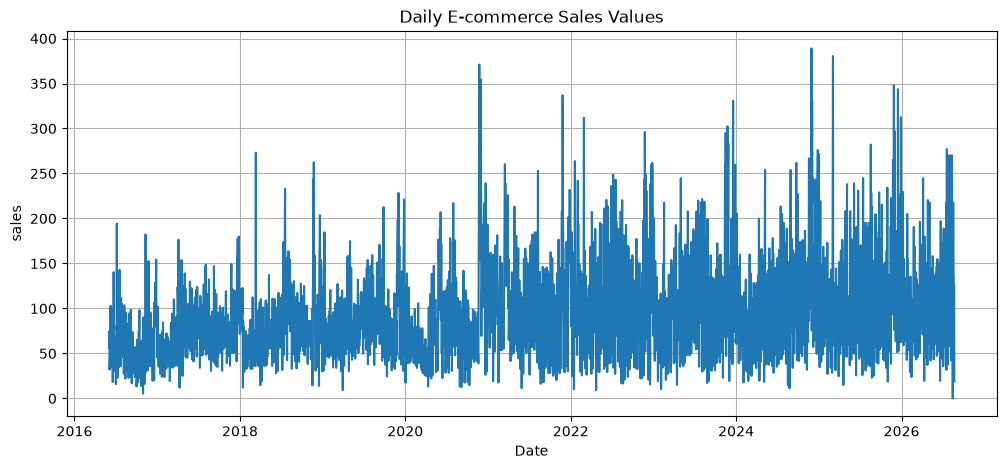

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(data["sales"])
plt.title("Daily E-commerce Sales Values")
plt.xlabel("Date")
plt.ylabel("sales")
plt.grid(True)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(data["sales"])
# Output the results
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -4.672400
p-value: 0.000095


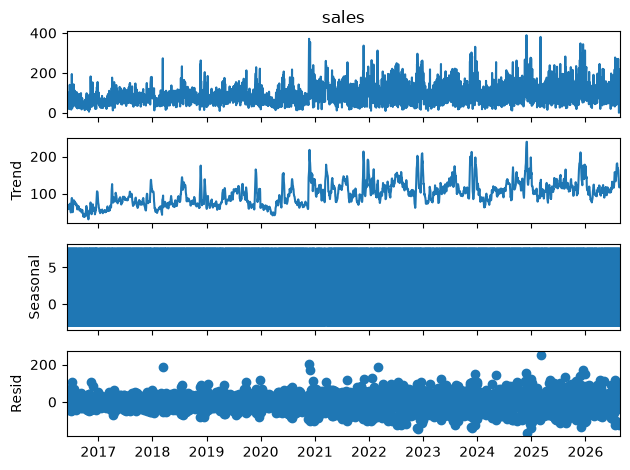

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ETS Decomposition
result = seasonal_decompose(
    data["sales"],
    model="additive",
    period=6
)

result.plot()
plt.show()


In [9]:
#keep the original data for later evaluation!
data2 = data.copy()

In [10]:
model_results = []

In [11]:
#Will use data for training, validation and testing up untill 27/6/2026
data = data.loc[:"2026-06-27"]

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np
# Extract the values
values = data["sales"].values.astype(np.float32)

# Split into training validation and testing
n = len(values)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_series = values[:train_end]
valid_series = values[train_end:valid_end]
test_series = values[valid_end:]

# Print the length of the datasets to check
print("Number of training samples   : ",len(train_series))
print("Number of validation samples : ",len(valid_series))
print("Number of testing samples    : ",len(test_series))

# Scale the data
scaler = StandardScaler()

# Reshape is required for the scaler
train_series_reshaped = train_series.reshape(-1, 1)
scaler.fit(train_series_reshaped)

# Transform
train_series_scaled = scaler.transform(train_series.reshape(-1, 1)).flatten()
valid_series_scaled = scaler.transform(valid_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

# Function to be used for inverse transformation
def inverse_transform(series, scaler):
    return scaler.inverse_transform(series.reshape(-1, 1)).reshape(series.shape)

Number of training samples   :  2141
Number of validation samples :  459
Number of testing samples    :  459


Shape of Training data   :  (2110, 26, 1) (2110, 6, 1)
Shape of Validation data :  (428, 26, 1) (428, 6, 1)
Shape of Testing data    :  (428, 26, 1) (428, 6, 1)


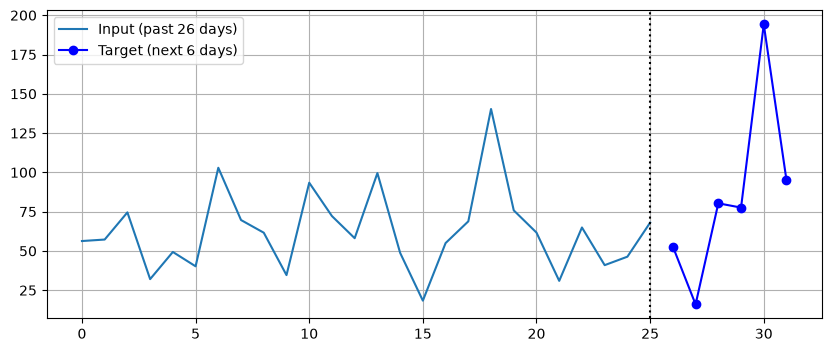

In [13]:
# Past and Future steps
#Monthly transactions are 26 days and we want to predict the next 6 days that is a typical week of sales.
past_steps = 26
future_steps = 6

# Function that makes windows of data to be used with the RNNs
def make_windows(series, past_steps, future_steps):
    X, Y = [], []
    for i in range(len(series) - past_steps - future_steps + 1):
        past = series[i:i + past_steps]
        future = series[i + past_steps:i + past_steps + future_steps]
        X.append(past)
        Y.append(future)
    X = np.array(X)[..., np.newaxis]
    Y = np.array(Y)[..., np.newaxis]
    return X, Y

# Make windows for all datasets
X_train, Y_train = make_windows(train_series_scaled, past_steps, future_steps)
X_valid, Y_valid = make_windows(valid_series_scaled, past_steps, future_steps)
X_test, Y_test = make_windows(test_series_scaled, past_steps, future_steps)

# Print the shapes to ensure they are conforming
print("Shape of Training data   : ", X_train.shape, Y_train.shape)
print("Shape of Validation data : ", X_valid.shape, Y_valid.shape)
print("Shape of Testing data    : ", X_test.shape, Y_test.shape)

# Visualize one training sample and its target
def plot_series(input_seq, target_seq=None, pred_seq=None):
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(input_seq)), input_seq[:, 0], label="Input (past 26 days)")
    
    if target_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(target_seq)),
            target_seq[:, 0],
            "bo-",
            label="Target (next 6 days)"
        )
    
    if pred_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(pred_seq)),
            pred_seq[:, 0],
            "rx--",
            label="Prediction"
        )
    
    plt.axvline(len(input_seq) - 1, color="k", linestyle=":")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_series(inverse_transform(X_train[0],scaler), inverse_transform(Y_train[0],scaler))


E0000 00:00:1788082897.687404  165909 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 26, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 26, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,446 (21.27 KB)

 Trainable params: 5,446 (21.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.4205 - mae: 0.7829 - val_loss: 0.4539 - val_mae: 0.8221
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3426 - mae: 0.6841 - val_loss: 0.4362 - val_mae: 0.7978
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3219 - mae: 0.6558 - val_loss: 0.4325 - val_mae: 0.7931
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3115 - mae: 0.6432 - val_loss: 0.4250 - val_mae: 0.7828
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3029 - mae: 0.6316 - val_loss: 0.4185 - val_mae: 0.7741
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2987 - mae: 0.6263 - val_loss: 0.4136 - val_mae: 0.7674
Epoch 7/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2937 - mae: 0.6175 - val_loss: 0.4098 - val_mae: 0.7620
Epoch 8/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2909 - mae: 0.6153 - val_loss: 0.4056 - val_mae: 0.7561
Epoch 9/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - lo

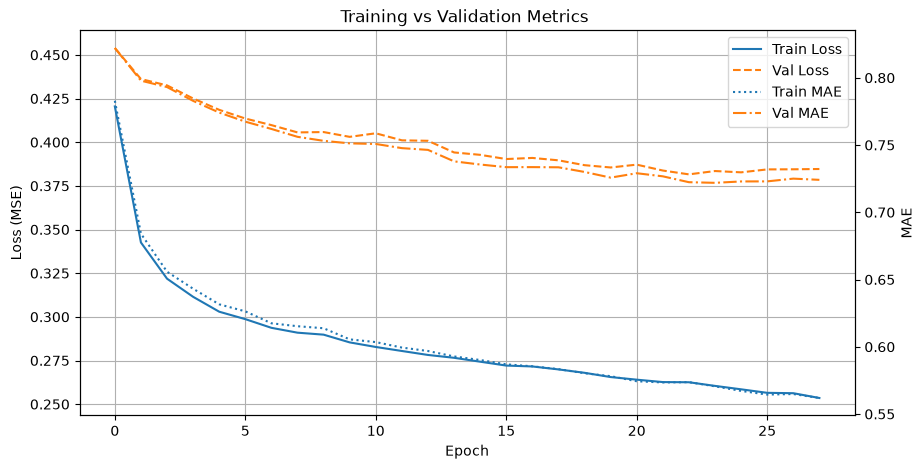

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Example 0


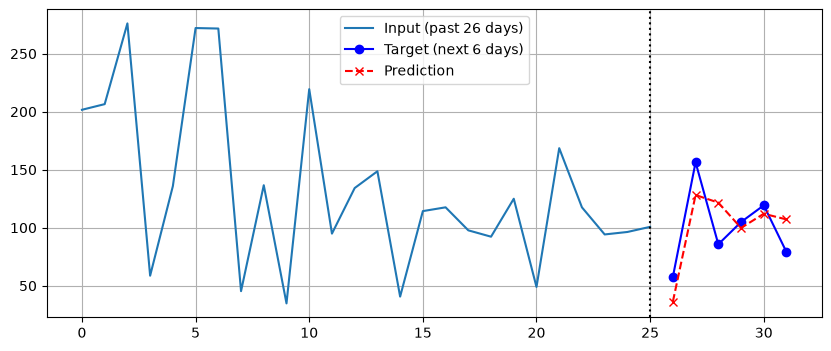

Example 1


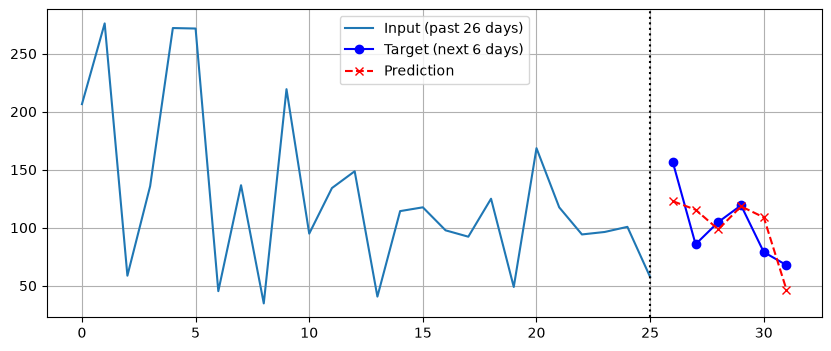

Example 2


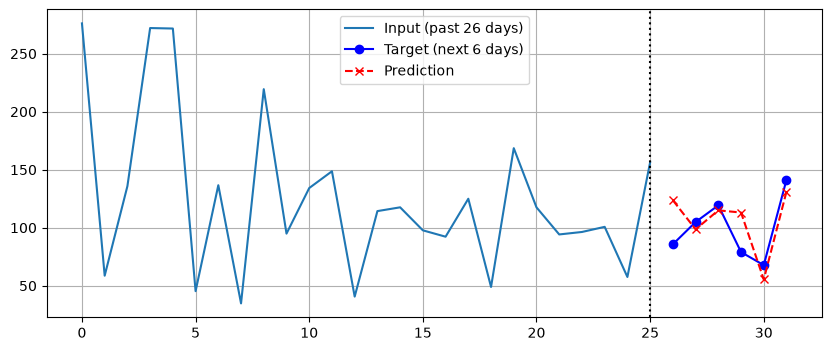

Example 3


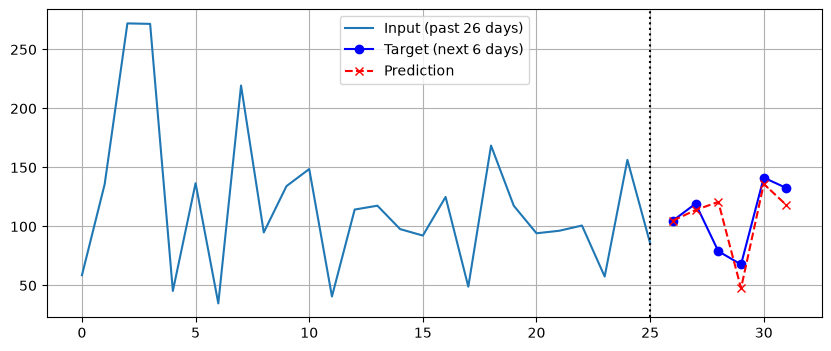

Example 4


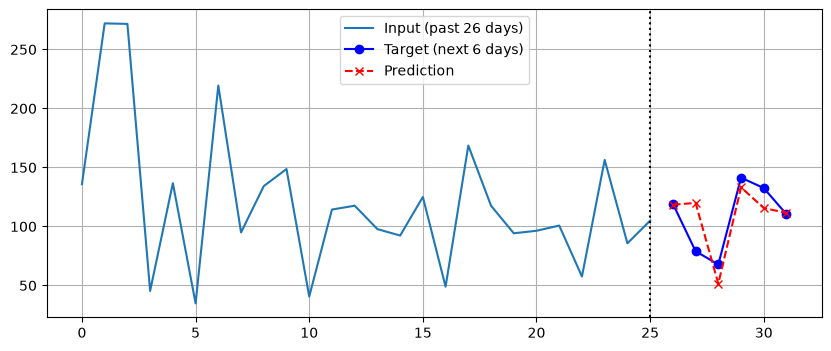

Example 5


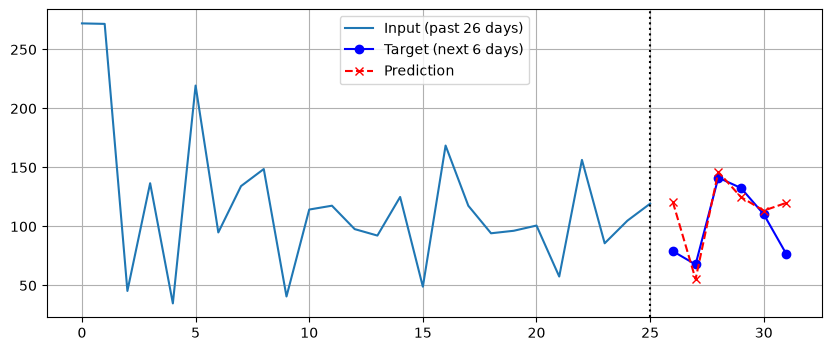

RNN MAE: 32.57257080078125
RNN RMSE: 48.00275802612305


In [14]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Number of epochs
epochs = 200

# Create default RNN
model_rnn = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(future_steps),
    keras.layers.Reshape([future_steps, 1])
])

# Compile the model
model_rnn.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_rnn.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_valid, Y_valid),
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_rnn.history["loss"], label="Train Loss")
ax1.plot(history_rnn.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_rnn.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_rnn.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_rnn = model_rnn.predict(X_test)

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_rnn[i],scaler)
    )

# MAE and RMSE for RNN
mae_rnn = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

rmse_rnn = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

# Print MAE and RMSE
print("RNN MAE:", mae_rnn)
print("RNN RMSE:", rmse_rnn)

model_results.append({
    "Model": "RNN",
    "MAE": mae_rnn,
    "RMSE": rmse_rnn
})


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 26, 32)         │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 26, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 26, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26, 6)          │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,230 (63.40 KB)

 Trainable params: 16,230 (63.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.3432 - mae: 0.6839 - val_loss: 0.5230 - val_mae: 0.8976
Epoch 2/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3324 - mae: 0.6671 - val_loss: 0.5151 - val_mae: 0.8891
Epoch 3/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3270 - mae: 0.6602 - val_loss: 0.4992 - val_mae: 0.8716
Epoch 4/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3203 - mae: 0.6524 - val_loss: 0.4659 - val_mae: 0.8324
Epoch 5/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3099 - mae: 0.6400 - val_loss: 0.4314 - val_mae: 0.7893
Epoch 6/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2998 - mae: 0.6273 - val_loss: 0.4022 - val_mae: 0.7532
Epoch 7/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.2908 - mae: 0.6147 - val_loss: 0.3880 - val_mae: 0.7333
Epoch 8/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2842 - mae: 0.6046 - val_loss: 0.3818 - val_mae: 0.7231
Epoch 9/200
132/132 ━━━━━━━━━━━━━━━━━━━━

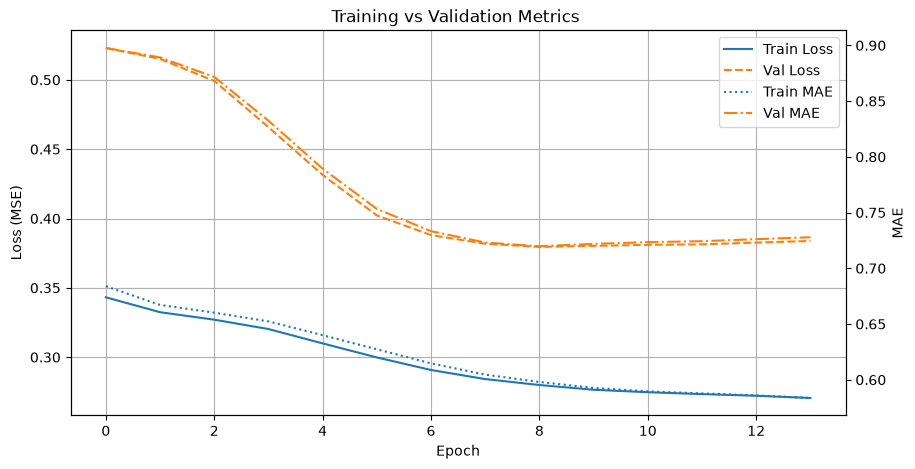

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Example 0


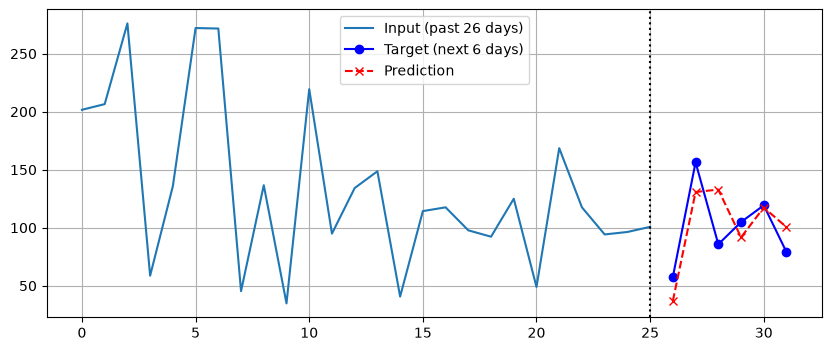

Example 1


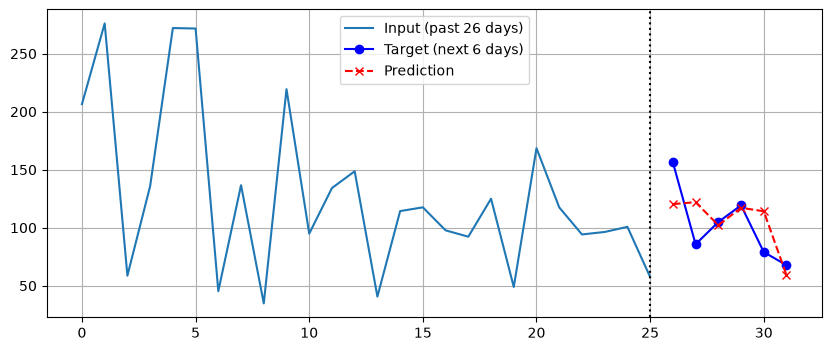

Example 2


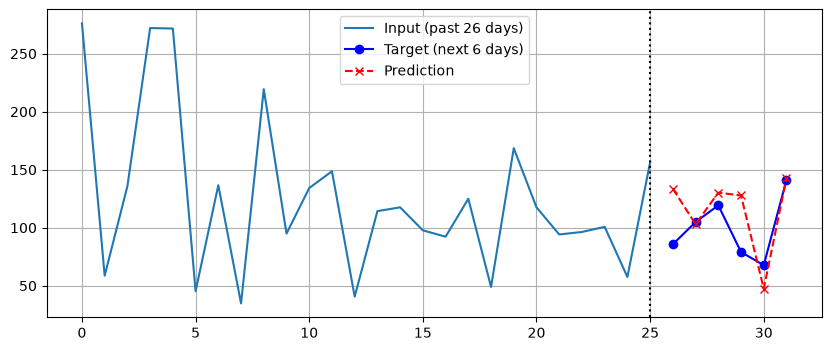

Example 3


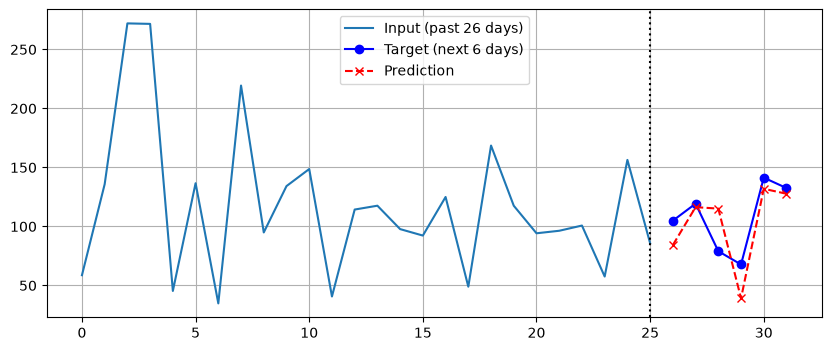

Example 4


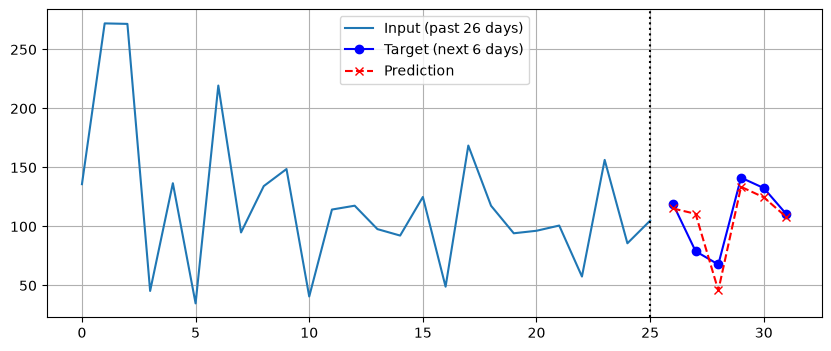

Example 5


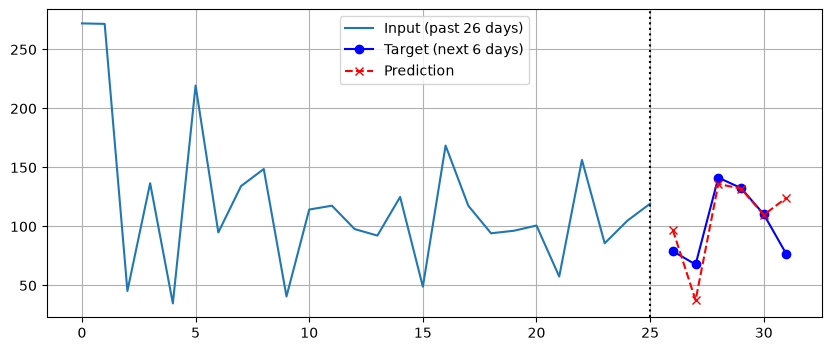

GRU MAE: 33.2942008972168
GRU RMSE: 48.35763168334961


In [15]:
# Function what creates windows
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

# Function that creates the tensor form for training
def to_seq2seq_dataset(series, seq_length=past_steps, ahead=future_steps, target_col=0, batch_size=16, shuffle=False, seed=42):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0, :], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

train_series_scaled_seq = to_seq2seq_dataset(train_series_scaled.reshape(-1, 1))
valid_series_scaled_seq = to_seq2seq_dataset(valid_series_scaled.reshape(-1, 1))
test_series_scaled_seq = to_seq2seq_dataset(test_series_scaled.reshape(-1, 1))

# Create default GRU
model_gru = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dense(future_steps)
])

# Compile the model
model_gru.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_gru.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history_gru = model_gru.fit(
    train_series_scaled_seq,
    epochs=epochs,
    validation_data=valid_series_scaled_seq,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_gru.history["loss"], label="Train Loss")
ax1.plot(history_gru.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_gru.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_gru.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_gru = model_gru.predict(X_test)

# Keep only the prediction at the last input time step
Y_pred_gru = Y_pred_gru[:, -1, :]          # shape: (n_samples, future_steps)

# Reshape to match Y_test: (n_samples, future_steps, 1)
Y_pred_gru = Y_pred_gru[..., np.newaxis]

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_gru[i],scaler)
    )

# MAE and RMSE for RNN
mae_gru = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

rmse_gru = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

# Print MAE and RMSE
print("GRU MAE:", mae_gru)
print("GRU RMSE:", rmse_gru)

model_results.append({
    "Model": "GRU",
    "MAE": mae_gru,
    "RMSE": rmse_gru
})


In [16]:

# naive forecast: tomorrow = today
naive_pred = test_series[:-1]
naive_true = test_series[1:]

naive_mae = mean_absolute_error(naive_true, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(naive_true, naive_pred))

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

model_results.append({
    "Model": "Naive",
    "MAE": naive_mae,
    "RMSE": naive_rmse
})

Naive MAE: 62.35860824584961
Naive RMSE: 81.80078041058808


In [17]:
#Calculate Arima and Sarima models as baseline to compare with the results of the NNs
arima_model = ARIMA(train_series, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_series))

arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")

model_results.append({
    "Model": "ARIMA",
    "MAE": arima_mae,
    "RMSE": arima_rmse
})


# Set s=7 if keeping a natural week, or s=6 if you dropped Sundays.
sarima_model = SARIMAX(
    train_series, 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 6) 
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test_series))

sarima_mae = mean_absolute_error(test_series, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_series, sarima_pred))

print(f"SARIMA MAE: {sarima_mae:.2f}")
print(f"SARIMA RMSE: {sarima_rmse:.2f}")

model_results.append({
    "Model": "SARIMA",
    "MAE": sarima_mae,
    "RMSE": sarima_rmse
})

ARIMA MAE: 41.62
ARIMA RMSE: 55.78
SARIMA MAE: 42.65
SARIMA RMSE: 56.80


I will now transform the data by adding all Sundays and with 3 new columns indicating if its Sundau, Monday and Saturday. Reasoning is that this way the model will predict 7 days instead of 6 while changing the window to 28 from 26. Also since the e-shop is usually closed Sundays and always Saturday is open half the normal hours I want the model to capture that . As a result Monday has higher daily sales than the other days and Saturday has less than Friday.

In [18]:
# create full daily date range
full_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="D"
)

# add missing days
data = data.reindex(full_index)

# fill missing sales with 0
data["sales"] = data["sales"].fillna(0)

# date features
data["is_monday"] = (data.index.weekday == 0).astype(np.float32)
data["is_saturday"] = (data.index.weekday == 5).astype(np.float32)
data["is_sunday"] = (data.index.weekday == 6).astype(np.float32)

In [19]:
past_steps = 28
future_steps = 7
batch_size = 16
epochs = 200

In [20]:
sales_values = data["sales"].values.astype(np.float32)

n = len(sales_values)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_sales = sales_values[:train_end]
valid_sales = sales_values[train_end:valid_end]
test_sales = sales_values[valid_end:]

scaler = StandardScaler()
scaler.fit(train_sales.reshape(-1, 1))

train_sales_scaled = scaler.transform(train_sales.reshape(-1, 1)).flatten()
valid_sales_scaled = scaler.transform(valid_sales.reshape(-1, 1)).flatten()
test_sales_scaled = scaler.transform(test_sales.reshape(-1, 1)).flatten()

In [21]:
features = data[["is_monday", "is_saturday", "is_sunday"]].values.astype(np.float32)

train_features = features[:train_end]
valid_features = features[train_end:valid_end]
test_features = features[valid_end:]

train_series_scaled = np.column_stack([train_sales_scaled, train_features])
valid_series_scaled = np.column_stack([valid_sales_scaled, valid_features])
test_series_scaled = np.column_stack([test_sales_scaled, test_features])

In [22]:
train_series_scaled_seq = to_seq2seq_dataset(
    train_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size,
    shuffle=True
)

valid_series_scaled_seq = to_seq2seq_dataset(
    valid_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size
)

test_series_scaled_seq = to_seq2seq_dataset(
    test_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size
)

In [23]:
for X_batch, Y_batch in train_series_scaled_seq.take(1):
    print("X_batch:", X_batch.shape)
    print("Y_batch:", Y_batch.shape)

X_batch: (16, 28, 4)
Y_batch: (16, 28, 7)


In [24]:
def dataset_to_numpy(ds):
    X_list = []
    Y_list = []

    for X_batch, Y_batch in ds:
        X_list.append(X_batch.numpy())
        Y_list.append(Y_batch.numpy())

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)

    return X, Y

In [25]:
X_train, Y_train = dataset_to_numpy(train_series_scaled_seq)
X_valid, Y_valid = dataset_to_numpy(valid_series_scaled_seq)
X_test, Y_test = dataset_to_numpy(test_series_scaled_seq)

In [26]:
#New GRU model with 4 inputs instead of 1
new_gru = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 4]),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dense(future_steps)
])

# Compile the model
new_gru.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
new_gru.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history_new_gru = new_gru.fit(
    train_series_scaled_seq,
    epochs=epochs,
    validation_data=valid_series_scaled_seq,
    callbacks=[early_stopping],
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 28, 32)         │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 28, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 28, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28, 7)          │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,551 (64.65 KB)

 Trainable params: 16,551 (64.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2979 - mae: 0.6290 - val_loss: 0.3139 - val_mae: 0.6313
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2009 - mae: 0.4800 - val_loss: 0.2763 - val_mae: 0.5649
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1910 - mae: 0.4579 - val_loss: 0.2717 - val_mae: 0.5563
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1879 - mae: 0.4511 - val_loss: 0.2667 - val_mae: 0.5491
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1858 - mae: 0.4463 - val_loss: 0.2623 - val_mae: 0.5422
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.1848 - mae: 0.4440 - val_loss: 0.2604 - val_mae: 0.5394
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1835 - mae: 0.4419 - val_loss: 0.2596 - val_mae: 0.5387
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1823 - mae: 0.4394 - val_loss: 0.2591 - val_mae: 0.5393
Epoch 9/200
159/159 ━━━━━━━━━━━━━━━━━━

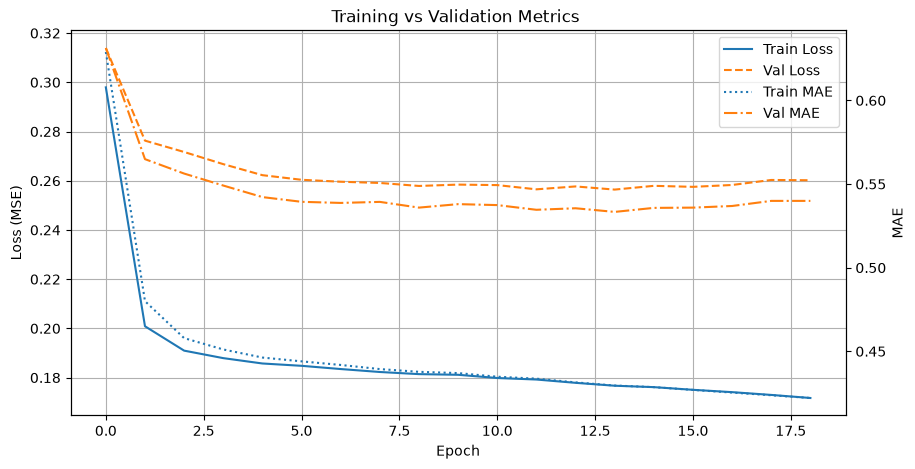

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Raw Y_test shape: (518, 28, 7)
Raw Y_pred_new_gru shape: (518, 28, 7)


In [27]:
# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_new_gru .history["loss"], label="Train Loss")
ax1.plot(history_new_gru .history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_new_gru .history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_new_gru .history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict
Y_pred_new_gru = new_gru.predict(X_test)

print("Raw Y_test shape:", Y_test.shape)
print("Raw Y_pred_new_gru shape:", Y_pred_new_gru.shape)



Final Y_test_last shape: (518, 7, 1)
Final Y_pred_new_gru shape: (518, 7, 1)
NEW GRU MAE: 28.303163528442383
NEW GRU RMSE: 44.559814453125
Example 0


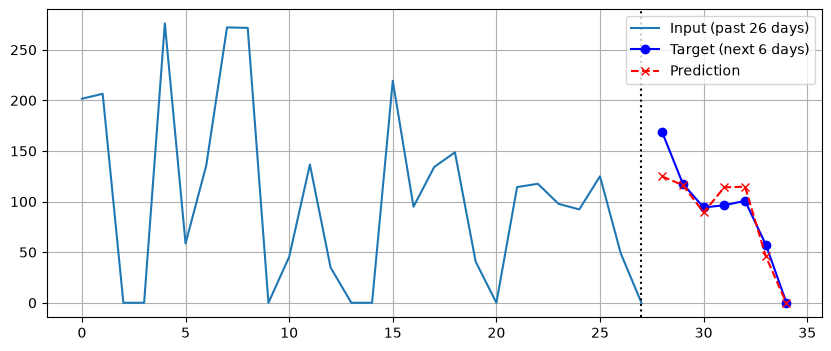

Example 1


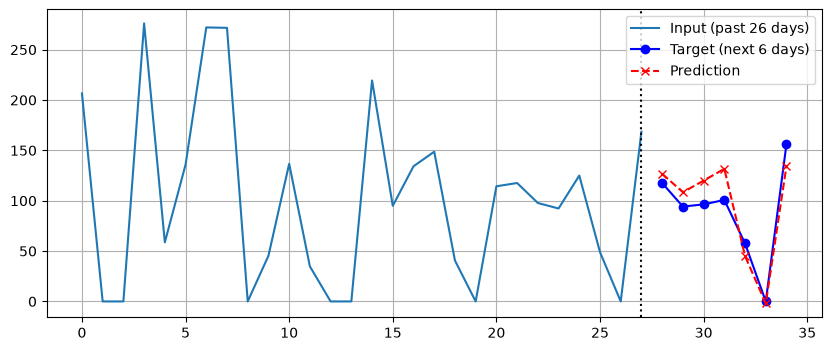

Example 2


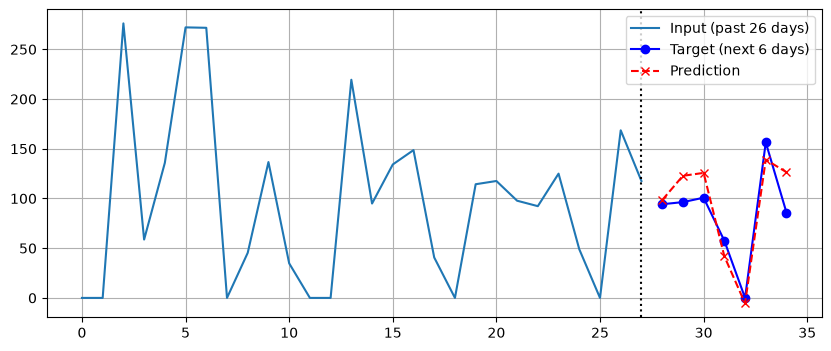

Example 3


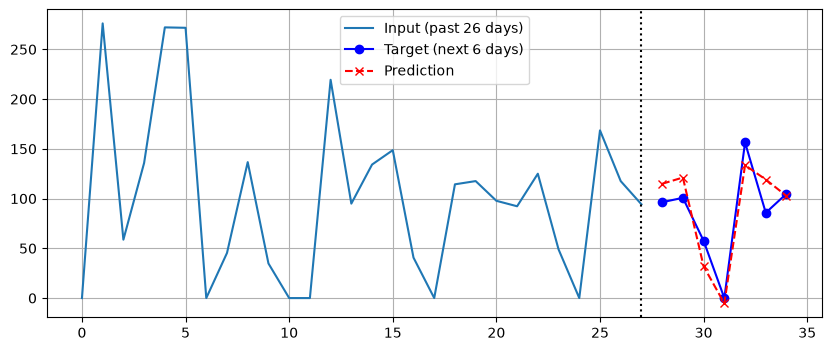

Example 4


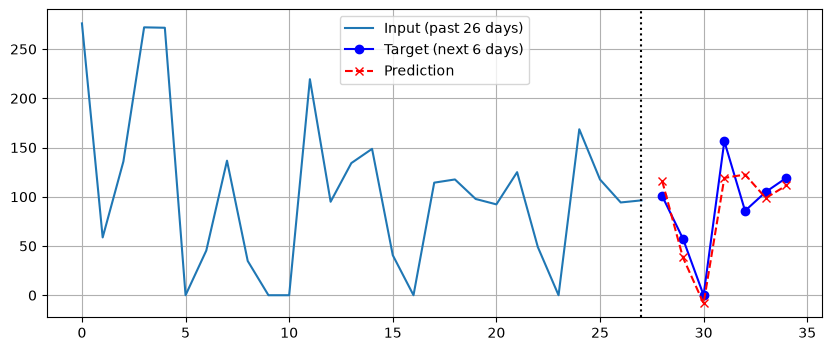

Example 5


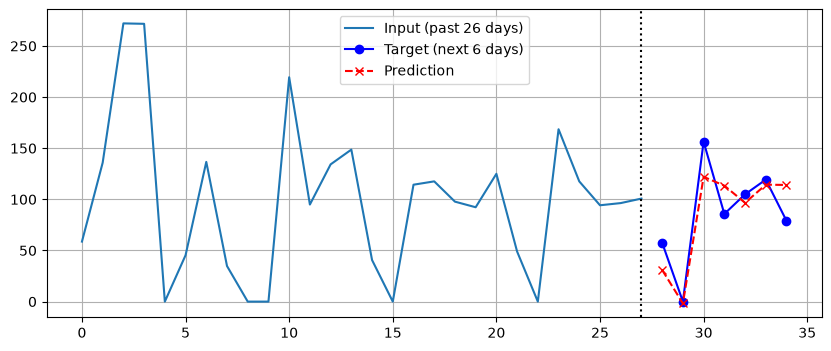

In [28]:
# Keep only last timestep forecast
Y_pred_new_gru = Y_pred_new_gru[:, -1, :]              # (samples, future_steps)
Y_pred_new_gru = Y_pred_new_gru[..., np.newaxis]       # (samples, future_steps, 1)

# Keep only last timestep target
Y_test_last = Y_test[:, -1, :]                         # (samples, future_steps)
Y_test_last = Y_test_last[..., np.newaxis]             # (samples, future_steps, 1)

print("Final Y_test_last shape:", Y_test_last.shape)
print("Final Y_pred_new_gru shape:", Y_pred_new_gru.shape)

mae_new_gru = mean_absolute_error(
    inverse_transform(Y_test_last.reshape(-1), scaler),
    inverse_transform(Y_pred_new_gru.reshape(-1), scaler)
)

rmse_new_gru = root_mean_squared_error(
    inverse_transform(Y_test_last.reshape(-1), scaler),
    inverse_transform(Y_pred_new_gru.reshape(-1), scaler)
)

print("NEW GRU MAE:", mae_new_gru)
print("NEW GRU RMSE:", rmse_new_gru)

for i in range(6):
    print(f"Example {i}")

    plot_series(
        inverse_transform(X_test[i, :, 0].reshape(-1, 1), scaler),
        inverse_transform(Y_test_last[i].reshape(-1, 1), scaler),
        inverse_transform(Y_pred_new_gru[i].reshape(-1, 1), scaler)
    )

In [29]:
model_results.append({
    "Model": "NEW GRU",
    "MAE": float(mae_new_gru),
    "RMSE": float(rmse_new_gru)
})

In [30]:
results_df = pd.DataFrame(model_results)
results_df.sort_values("MAE")

,Model,MAE,RMSE
5,NEW GRU,28.303164,44.559814
0,RNN,32.572571,48.002758
1,GRU,33.294201,48.357632
3,ARIMA,41.622227,55.783391
4,SARIMA,42.647306,56.799006
2,Naive,62.358608,81.800780


In [31]:
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape)
print("Y_valid:", Y_valid.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (2541, 28, 4)
Y_train: (2541, 28, 7)
X_valid: (518, 28, 4)
Y_valid: (518, 28, 7)
X_test: (518, 28, 4)
Y_test: (518, 28, 7)


In [32]:
train_dates = data.index[:train_end]
valid_dates = data.index[train_end:valid_end]
test_dates = data.index[valid_end:]

print("Train:", train_dates.min(), "to", train_dates.max())
print("Valid:", valid_dates.min(), "to", valid_dates.max())
print("Test :", test_dates.min(), "to", test_dates.max())

print(train_dates.max() < valid_dates.min())
print(valid_dates.max() < test_dates.min())

Train: 2016-06-01 00:00:00 to 2023-06-19 00:00:00
Valid: 2023-06-20 00:00:00 to 2024-12-22 00:00:00
Test : 2024-12-23 00:00:00 to 2026-06-27 00:00:00
True
True


In [33]:
Y_test_eval = Y_test_last[::future_steps]
Y_pred_eval = Y_pred_new_gru[::future_steps]

mae_strict = mean_absolute_error(
    inverse_transform(Y_test_eval.reshape(-1), scaler),
    inverse_transform(Y_pred_eval.reshape(-1), scaler)
)

rmse_strict = root_mean_squared_error(
    inverse_transform(Y_test_eval.reshape(-1), scaler),
    inverse_transform(Y_pred_eval.reshape(-1), scaler)
)

print("Strict non-overlap MAE:", mae_strict)
print("Strict non-overlap RMSE:", rmse_strict)

Strict non-overlap MAE: 27.818984985351562
Strict non-overlap RMSE: 44.505306243896484


In [34]:
model_results.append({
    "Model": "NEW GRU 28/7 + Weekday Flags Strict",
    "MAE": float(mae_strict),
    "RMSE": float(rmse_strict)
})

Now that we have our models I will use actual data for prediction and make comparisons. I have seperated the data from 26/6 till 22/8 and I will use each week to make Predicitions without giving the actual data to the model. Then I will compare the results , add the week to the data retrain and make a new prediction for the next week again without giving the results to the model.

In [35]:
# Actual sales for real walk-forward evaluation
actual_sales = data2.loc["2026-06-29":"2026-08-22"].copy()

# Keep only Monday-Saturday
actual_sales = actual_sales[actual_sales.index.weekday != 6].copy()

# Keep only target column
actual_sales = actual_sales[["sales"]].copy()

# Add useful evaluation columns
actual_sales["forecast_date"] = actual_sales.index
actual_sales["week_start"] = actual_sales["forecast_date"] - pd.to_timedelta(
    actual_sales["forecast_date"].dt.weekday, unit="D"
)

actual_sales["horizon"] = actual_sales.groupby("week_start").cumcount() + 1

# Clean column names
actual_sales = actual_sales.rename(columns={"sales": "y_true"})

# Final shape
actual_sales = actual_sales.reset_index(drop=True)

actual_sales.head(10)

,y_true,forecast_date,week_start,horizon
0,173.73,2026-06-29,2026-06-29,1
1,138.39,2026-06-30,2026-06-29,2
2,132.92,2026-07-01,2026-06-29,3
3,172.33,2026-07-02,2026-06-29,4
4,125.24,2026-07-03,2026-06-29,5
5,35.86,2026-07-04,2026-06-29,6
6,188.85,2026-07-06,2026-07-06,1
7,125.74,2026-07-07,2026-07-06,2
8,111.85,2026-07-08,2026-07-06,3
9,124.48,2026-07-09,2026-07-06,4


In [36]:
actual_sales.groupby("week_start").size()

week_start
2026-06-29    6
2026-07-06    6
2026-07-13    6
2026-07-20    6
2026-07-27    6
2026-08-03    6
2026-08-10    6
2026-08-17    6
dtype: int64

In [37]:
past_steps = 26
future_steps = 6
target_col = "sales"

def scale_current_history(current_history, target_col="sales"):
    scaler = StandardScaler()

    sales = current_history[target_col].values.astype(np.float32)
    sales_scaled = scaler.fit_transform(sales.reshape(-1, 1)).astype(np.float32)

    return sales_scaled, scaler


In [38]:
def prepare_base_model_data(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    batch_size=16
):
    sales_scaled, scaler = scale_current_history(current_history, target_col=target_col)

    # RNN: seq-to-vector
    X_rnn, Y_rnn = make_windows(
        sales_scaled.reshape(-1),
        past_steps=past_steps,
        future_steps=future_steps
    )

    # GRU: seq-to-seq
    gru_ds = to_seq2seq_dataset(
        sales_scaled,
        seq_length=past_steps,
        ahead=future_steps,
        target_col=0,
        batch_size=batch_size,
        shuffle=False,
        seed=42
    )

    # Last known window for next-week prediction
    X_next = sales_scaled[-past_steps:].reshape(1, past_steps, 1).astype(np.float32)

    return {
        "sales_scaled": sales_scaled,
        "scaler": scaler,
        "X_rnn": X_rnn,
        "Y_rnn": Y_rnn,
        "gru_ds": gru_ds,
        "X_next": X_next
    }

In [39]:
holdout_start = pd.Timestamp("2026-06-29")

current_history = data2.loc[data2.index < holdout_start].copy()
base_data = prepare_base_model_data(
    current_history,
    target_col="sales",
    past_steps=past_steps,
    future_steps=future_steps,
    batch_size=batch_size
)

In [40]:
print(current_history.index.min())
print(current_history.index.max())

2016-06-01 00:00:00
2026-06-27 00:00:00


In [41]:
print("RNN X:", base_data["X_rnn"].shape)
print("RNN Y:", base_data["Y_rnn"].shape)
print("Next window:", base_data["X_next"].shape)

for X_batch, Y_batch in base_data["gru_ds"].take(1):
    print("GRU X batch:", X_batch.shape)
    print("GRU Y batch:", Y_batch.shape)

RNN X: (3028, 26, 1)
RNN Y: (3028, 6, 1)
Next window: (1, 26, 1)
GRU X batch: (16, 26, 1)
GRU Y batch: (16, 26, 6)


In [42]:
def split_windows_time_order(X, Y, valid_ratio=0.15):
    valid_size = int(len(X) * valid_ratio)

    X_train = X[:-valid_size]
    Y_train = Y[:-valid_size]

    X_valid = X[-valid_size:]
    Y_valid = Y[-valid_size:]

    return X_train, Y_train, X_valid, Y_valid

In [43]:
def build_base_rnn(past_steps=26, future_steps=6):
    model_rnn = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, 1]),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(future_steps),
        keras.layers.Reshape([future_steps, 1])
    ])

    model_rnn.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model_rnn

In [44]:
def train_predict_rnn(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    epochs=200,
    batch_size=16
):
    base_data = prepare_base_model_data(
        current_history=current_history,
        target_col=target_col,
        past_steps=past_steps,
        future_steps=future_steps,
        batch_size=batch_size
    )

    X_rnn = base_data["X_rnn"]
    Y_rnn = base_data["Y_rnn"]
    X_next = base_data["X_next"]
    scaler = base_data["scaler"]

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(X_rnn, Y_rnn)

    model_rnn = build_base_rnn(
        past_steps=past_steps,
        future_steps=future_steps
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history_rnn = model_rnn.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        verbose=1
    )

    y_pred_scaled = model_rnn.predict(X_next)
    y_pred = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_pred, model_rnn, history_rnn

In [45]:
rnn_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    print(f"Training RNN for week starting {week_start.date()}")

    # Only past data is allowed
    current_history = data2.loc[data2.index < week_start].copy()

    # Actual answers for this week
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    # Safety check
    if len(actual_week) != future_steps:
        print(f"Skipping {week_start.date()} - expected {future_steps} days, got {len(actual_week)}")
        continue

    # Train and predict
    y_pred, model_rnn, history_rnn = train_predict_rnn(
        current_history=current_history,
        target_col="sales",
        past_steps=past_steps,
        future_steps=future_steps,
        epochs=epochs,
        batch_size=batch_size
    )
    print("Predict week:", week_start.date())
    print("History ends:", current_history.index.max().date())
    print("Actual week rows:", len(actual_week))
    # Save prediction table
    week_result = actual_week.copy()
    week_result["model"] = "RNN"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    rnn_results.append(week_result)

Training RNN for week starting 2026-06-29
Epoch 1/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.3494 - mae: 0.6940 - val_loss: 0.3677 - val_mae: 0.7070
Epoch 2/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2923 - mae: 0.6178 - val_loss: 0.3561 - val_mae: 0.6822
Epoch 3/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2776 - mae: 0.5972 - val_loss: 0.3446 - val_mae: 0.6694
Epoch 4/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2690 - mae: 0.5848 - val_loss: 0.3379 - val_mae: 0.6584
Epoch 5/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2641 - mae: 0.5787 - val_loss: 0.3368 - val_mae: 0.6568
Epoch 6/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2589 - mae: 0.5709 - val_loss: 0.3339 - val_mae: 0.6541
Epoch 7/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2558 - mae: 0.5668 - val_loss: 0.3297 - val_mae: 0.6461
Epoch 8/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2546 - mae: 0.5642 - val_loss: 0.3292 - val_mae: 0.6470
E

In [46]:
rnn_results_df = pd.concat(rnn_results, ignore_index=True)

rnn_results_df.head()

,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,RNN,173.73,129.484375
1,2026-06-29,2026-06-30,2,RNN,138.39,143.280609
2,2026-06-29,2026-07-01,3,RNN,132.92,109.758621
3,2026-06-29,2026-07-02,4,RNN,172.33,99.267235
4,2026-06-29,2026-07-03,5,RNN,125.24,107.709846


In [47]:
mae_rnn_walkforward = mean_absolute_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

rmse_rnn_walkforward = root_mean_squared_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

print("RNN Walk-forward MAE:", mae_rnn_walkforward)
print("RNN Walk-forward RMSE:", rmse_rnn_walkforward)

RNN Walk-forward MAE: 32.21909806887309
RNN Walk-forward RMSE: 45.50964807311759


In [48]:
rnn_weekly_metrics = (
    rnn_results_df
    .groupby("week_start")
    .apply(lambda df: pd.Series({
        "MAE": mean_absolute_error(df["y_true"], df["y_pred"]),
        "RMSE": root_mean_squared_error(df["y_true"], df["y_pred"])
    }))
    .reset_index()
)

rnn_weekly_metrics

,week_start,MAE,RMSE
0,2026-06-29,31.052971,38.105894
1,2026-07-06,16.311963,20.882048
2,2026-07-13,29.207340,43.275733
3,2026-07-20,28.279364,43.308960
4,2026-07-27,47.844042,69.711142
5,2026-08-03,42.904251,49.948370
6,2026-08-10,37.834669,51.384276
7,2026-08-17,24.318186,30.620639


In [49]:
all_model_results = []

all_model_results.append(rnn_results_df)

In [50]:
def build_base_gru(past_steps=26, future_steps=6):
    model_gru = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, 1]),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dense(future_steps)
    ])

    model_gru.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model_gru

In [51]:
def train_predict_gru(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    epochs=200,
    batch_size=16
):
    sales_scaled, scaler = scale_current_history(
        current_history,
        target_col=target_col
    )

    # Create seq-to-seq dataset, no shuffle yet
    gru_ds_all = to_seq2seq_dataset(
        sales_scaled,
        seq_length=past_steps,
        ahead=future_steps,
        target_col=0,
        batch_size=batch_size,
        shuffle=False
    )

    X_gru, Y_gru = dataset_to_numpy(gru_ds_all)

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(
        X_gru,
        Y_gru
    )

    model_gru = build_base_gru(
        past_steps=past_steps,
        future_steps=future_steps
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history_gru = model_gru.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        shuffle=True,
        verbose=1
    )

    # Last known 26 days
    X_next = sales_scaled[-past_steps:].reshape(1, past_steps, 1).astype(np.float32)

    # Seq-to-seq prediction
    y_pred_scaled = model_gru.predict(X_next)

    # Take only last time step
    y_pred_scaled = y_pred_scaled[:, -1, :]      # shape: (1, 6)

    # Back to real scale
    y_pred = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_pred, model_gru, history_gru

In [52]:
gru_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    print(f"Training GRU for week starting {week_start.date()}")

    # only past data
    current_history = data2.loc[data2.index < week_start].copy()

    # real answers for this week
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != future_steps:
        print(f"Skipping {week_start.date()} - expected {future_steps} days, got {len(actual_week)}")
        continue

    y_pred, model_gru, history_gru = train_predict_gru(
        current_history=current_history,
        target_col="sales",
        past_steps=past_steps,
        future_steps=future_steps,
        epochs=epochs,
        batch_size=batch_size
    )

    week_result = actual_week.copy()
    week_result["model"] = "GRU"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    gru_results.append(week_result)

Training GRU for week starting 2026-06-29
Epoch 1/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.3215 - mae: 0.6549 - val_loss: 0.4363 - val_mae: 0.7921
Epoch 2/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2926 - mae: 0.6169 - val_loss: 0.3847 - val_mae: 0.7274
Epoch 3/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2578 - mae: 0.5694 - val_loss: 0.3573 - val_mae: 0.6844
Epoch 4/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2463 - mae: 0.5507 - val_loss: 0.3532 - val_mae: 0.6775
Epoch 5/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2425 - mae: 0.5445 - val_loss: 0.3532 - val_mae: 0.6777
Epoch 6/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2403 - mae: 0.5411 - val_loss: 0.3532 - val_mae: 0.6774
Epoch 7/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.2380 - mae: 0.5383 - val_loss: 0.3526 - val_mae: 0.6761
Epoch 8/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.2361 - mae: 0.5356 - val_loss: 0.3533 - val_mae: 0.676

In [53]:
gru_results_df = pd.concat(gru_results, ignore_index=True)

gru_results_df.head()

,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,GRU,173.73,139.996460
1,2026-06-29,2026-06-30,2,GRU,138.39,129.900284
2,2026-06-29,2026-07-01,3,GRU,132.92,101.487648
3,2026-06-29,2026-07-02,4,GRU,172.33,118.291733
4,2026-06-29,2026-07-03,5,GRU,125.24,105.549248


In [54]:
mae_gru_walkforward = mean_absolute_error(
    gru_results_df["y_true"],
    gru_results_df["y_pred"]
)

rmse_gru_walkforward = root_mean_squared_error(
    gru_results_df["y_true"],
    gru_results_df["y_pred"]
)

print("GRU Walk-forward MAE:", mae_gru_walkforward)
print("GRU Walk-forward RMSE:", rmse_gru_walkforward)

GRU Walk-forward MAE: 29.053584677378335
GRU Walk-forward RMSE: 41.19327941985254


Time to run the New GRU with all 4 weeks/7 days prediction


In [55]:
sundays = pd.date_range(data.index.min(), data.index.max(), freq="W-SUN")

data = data.reindex(data.index.union(sundays)).sort_index()

data.loc[data.index.dayofweek == 6, "sales"] = (
    data.loc[data.index.dayofweek == 6, "sales"].fillna(0)
)

In [56]:
past_steps_new = 28
future_steps_new = 7

In [57]:
def make_calendar_history(current_history, week_start, target_col="sales"):
    calendar_history = current_history[[target_col]].copy()
    calendar_history = calendar_history.sort_index()

    calendar_end = pd.Timestamp(week_start) - pd.Timedelta(days=1)

    full_index = pd.date_range(
        start=calendar_history.index.min(),
        end=calendar_end,
        freq="D"
    )

    calendar_history = calendar_history.reindex(full_index)

    # Missing calendar days = closed days
    calendar_history[target_col] = calendar_history[target_col].fillna(0)

    calendar_history["is_monday"] = (calendar_history.index.weekday == 0).astype(np.float32)
    calendar_history["is_saturday"] = (calendar_history.index.weekday == 5).astype(np.float32)
    calendar_history["is_sunday"] = (calendar_history.index.weekday == 6).astype(np.float32)

    return calendar_history

In [58]:
def scale_calendar_history(calendar_history, target_col="sales"):
    scaler = StandardScaler()

    sales = calendar_history[target_col].values.astype(np.float32)

    sales_scaled = scaler.fit_transform(
        sales.reshape(-1, 1)
    ).astype(np.float32).reshape(-1)

    flags = calendar_history[
        ["is_monday", "is_saturday", "is_sunday"]
    ].values.astype(np.float32)

    series_scaled = np.column_stack([sales_scaled, flags]).astype(np.float32)

    return series_scaled, scaler

In [59]:
def make_sunday_calendar_windows(
    calendar_history,
    series_scaled,
    past_steps=28,
    future_steps=7,
    target_col_index=0
):
    X, Y = [], []
    dates = calendar_history.index

    for i in range(len(series_scaled) - past_steps - future_steps + 1):
        input_end_date = dates[i + past_steps - 1]

        # input must end on Sunday
        if input_end_date.weekday() != 6:
            continue

        past = series_scaled[i:i + past_steps]
        future = series_scaled[
            i + past_steps:i + past_steps + future_steps,
            target_col_index
        ]

        X.append(past)
        Y.append(future)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)[..., np.newaxis]

    return X, Y

In [60]:
def build_new_gru(past_steps=28, future_steps=7, n_features=4):
    model = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, n_features]),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32),
        keras.layers.Dense(future_steps),
        keras.layers.Reshape([future_steps, 1])
    ])

    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model

In [61]:
def train_predict_new_gru(
    current_history,
    week_start,
    target_col="sales",
    past_steps=28,
    future_steps=7,
    epochs=200,
    batch_size=16
):
    tf.keras.backend.clear_session()

    calendar_history = make_calendar_history(
        current_history=current_history,
        week_start=week_start,
        target_col=target_col
    )

    series_scaled, scaler = scale_calendar_history(
        calendar_history,
        target_col=target_col
    )

    X, Y = make_sunday_calendar_windows(
        calendar_history=calendar_history,
        series_scaled=series_scaled,
        past_steps=past_steps,
        future_steps=future_steps
    )

    print("New GRU X:", X.shape)
    print("New GRU Y:", Y.shape)
    print("Calendar history ends:", calendar_history.index.max())

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(X, Y)

    model = build_new_gru(
        past_steps=past_steps,
        future_steps=future_steps,
        n_features=X.shape[-1]
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        shuffle=True,
        verbose=1
    )

    X_next = series_scaled[-past_steps:].reshape(
        1, past_steps, X.shape[-1]
    ).astype(np.float32)

    y_pred_scaled = model.predict(X_next)

    y_pred_7 = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    # Prediction is Monday-Sunday.
    # Main comparison is Monday-Saturday.
    y_pred_6 = y_pred_7[:6]

    return y_pred_6, y_pred_7, model, history

In [62]:
new_gru_results = []
new_gru_calendar_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"\nTraining New GRU for week: {week_start.date()}")

    # NO LEAK: only past data before this week
    current_history = data2.loc[data2.index < week_start].copy()

    # Mon-Sat actuals
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Problem: {week_start.date()} has {len(actual_week)} days, expected 6")
        continue

    # Predict
    y_pred_6, y_pred_7, model_new_gru, history_new_gru = train_predict_new_gru(
        current_history=current_history,
        week_start=week_start,
        target_col="sales",
        past_steps=past_steps_new,
        future_steps=future_steps_new,
        epochs=epochs,
        batch_size=batch_size
    )

    # Save Mon-Sat comparison
    week_result = actual_week.copy()
    week_result["model"] = "New GRU 28/7"
    week_result["y_pred"] = y_pred_6

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    new_gru_results.append(week_result)

    # Save full Mon-Sun prediction too
    calendar_dates = pd.date_range(start=week_start, periods=7, freq="D")

    calendar_week = pd.DataFrame({
        "week_start": week_start,
        "forecast_date": calendar_dates,
        "horizon": np.arange(1, 8),
        "model": "New GRU 28/7 Calendar",
        "y_pred": y_pred_7
    })

    calendar_week["y_true"] = (
        data2.reindex(calendar_dates)["sales"]
        .fillna(0)
        .values
    )

    calendar_week["is_sunday"] = calendar_week["forecast_date"].dt.weekday == 6

    new_gru_calendar_results.append(calendar_week)


Training New GRU for week: 2026-06-29
New GRU X: (521, 28, 4)
New GRU Y: (521, 7, 1)
Calendar history ends: 2026-06-28 00:00:00
Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.2940 - mae: 0.6273 - val_loss: 0.2236 - val_mae: 0.4861
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1840 - mae: 0.4518 - val_loss: 0.2135 - val_mae: 0.4642
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1715 - mae: 0.4209 - val_loss: 0.2091 - val_mae: 0.4558
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1689 - mae: 0.4147 - val_loss: 0.2084 - val_mae: 0.4621
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1697 - mae: 0.4156 - val_loss: 0.2086 - val_mae: 0.4610
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1687 - mae: 0.4144 - val_loss: 0.2082 - val_mae: 0.4629
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1678 - mae: 0.4114 - val_loss: 0.2078 - val_mae: 0.4601
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21m

In [63]:
new_gru_results_df = pd.concat(new_gru_results, ignore_index=True)
new_gru_calendar_results_df = pd.concat(new_gru_calendar_results, ignore_index=True)

In [64]:
mae_new_gru = mean_absolute_error(
    new_gru_results_df["y_true"],
    new_gru_results_df["y_pred"]
)

rmse_new_gru = root_mean_squared_error(
    new_gru_results_df["y_true"],
    new_gru_results_df["y_pred"]
)

print("New GRU Walk-forward MAE:", mae_new_gru)
print("New GRU Walk-forward RMSE:", rmse_new_gru)

New GRU Walk-forward MAE: 31.511498750050862
New GRU Walk-forward RMSE: 43.25248093290222


In [65]:
new_gru_weekly_metrics = (
    new_gru_results_df
    .groupby("week_start")
    .apply(lambda df: pd.Series({
        "MAE": mean_absolute_error(df["y_true"], df["y_pred"]),
        "RMSE": root_mean_squared_error(df["y_true"], df["y_pred"])
    }))
    .reset_index()
)

new_gru_weekly_metrics

,week_start,MAE,RMSE
0,2026-06-29,21.752672,27.236225
1,2026-07-06,16.116384,18.005800
2,2026-07-13,29.435335,42.533713
3,2026-07-20,32.454714,48.681732
4,2026-07-27,47.307067,66.201876
5,2026-08-03,39.098966,46.406474
6,2026-08-10,41.481365,48.595932
7,2026-08-17,24.445488,28.694154


In [66]:
new_gru_calendar_results_df[
    new_gru_calendar_results_df["is_sunday"]
][["week_start", "forecast_date", "y_true", "y_pred"]]

,week_start,forecast_date,y_true,y_pred
6,2026-06-29,2026-07-05,0.0,4.657173
13,2026-07-06,2026-07-12,0.0,2.159615
20,2026-07-13,2026-07-19,0.0,1.402222
27,2026-07-20,2026-07-26,0.0,6.185303
34,2026-07-27,2026-08-02,0.0,0.100769
41,2026-08-03,2026-08-09,0.0,1.666245
48,2026-08-10,2026-08-16,0.0,3.521950
55,2026-08-17,2026-08-23,0.0,-1.860924


Modelcomparing

set naive and arima/asarima baselines

In [67]:
naive_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    # previous 6 working days = previous week Mon-Sat
    y_pred = current_history["sales"].values[-6:]

    week_result = actual_week.copy()
    week_result["model"] = "Naive"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    naive_results.append(week_result)

naive_results_df = pd.concat(naive_results, ignore_index=True)

In [68]:
from statsmodels.tsa.arima.model import ARIMA

arima_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"Training ARIMA for week: {week_start.date()}")

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    train_series_arima = current_history["sales"].astype(float).values

    arima_model = ARIMA(train_series_arima, order=(1, 1, 1))
    arima_fit = arima_model.fit()

    y_pred = arima_fit.forecast(steps=6)

    week_result = actual_week.copy()
    week_result["model"] = "ARIMA"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    arima_results.append(week_result)

arima_results_df = pd.concat(arima_results, ignore_index=True)

Training ARIMA for week: 2026-06-29
Training ARIMA for week: 2026-07-06
Training ARIMA for week: 2026-07-13
Training ARIMA for week: 2026-07-20
Training ARIMA for week: 2026-07-27
Training ARIMA for week: 2026-08-03
Training ARIMA for week: 2026-08-10
Training ARIMA for week: 2026-08-17


In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"Training SARIMA for week: {week_start.date()}")

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    train_series_sarima = current_history["sales"].astype(float).values

    sarima_model = SARIMAX(
        train_series_sarima,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 6),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima_model.fit(disp=False)

    y_pred = sarima_fit.forecast(steps=6)

    week_result = actual_week.copy()
    week_result["model"] = "SARIMA"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    sarima_results.append(week_result)

sarima_results_df = pd.concat(sarima_results, ignore_index=True)

Training SARIMA for week: 2026-06-29
Training SARIMA for week: 2026-07-06
Training SARIMA for week: 2026-07-13
Training SARIMA for week: 2026-07-20
Training SARIMA for week: 2026-07-27
Training SARIMA for week: 2026-08-03
Training SARIMA for week: 2026-08-10
Training SARIMA for week: 2026-08-17


In [70]:


# Collect all result DataFrames that exist
result_frames = []

possible_results = [
    "naive_results_df",
    "arima_results_df",
    "sarima_results_df",
    "rnn_results_df",
    "gru_results_df",
    "new_gru_results_df"
]

for df_name in possible_results:
    if df_name in globals():
        print("Found:", df_name)
        result_frames.append(globals()[df_name].copy())
    else:
        print("Missing:", df_name)

all_results_df = pd.concat(result_frames, ignore_index=True)

all_results_df = all_results_df.sort_values(
    ["week_start", "forecast_date", "model"]
).reset_index(drop=True)

all_results_df.head()

Found: naive_results_df
Found: arima_results_df
Found: sarima_results_df
Found: rnn_results_df
Found: gru_results_df
Found: new_gru_results_df


,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,ARIMA,173.73,105.662100
1,2026-06-29,2026-06-29,1,GRU,173.73,139.996460
2,2026-06-29,2026-06-29,1,Naive,173.73,159.740000
3,2026-06-29,2026-06-29,1,New GRU 28/7,173.73,139.429626
4,2026-06-29,2026-06-29,1,RNN,173.73,129.484375


In [71]:
overall_rows = []

for model_name, df_model in all_results_df.groupby("model"):
    overall_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(df_model["y_true"], df_model["y_pred"]),
        "RMSE": root_mean_squared_error(df_model["y_true"], df_model["y_pred"])
    })

overall_metrics_df = pd.DataFrame(overall_rows).sort_values("MAE").reset_index(drop=True)

overall_metrics_df

,Model,MAE,RMSE
0,GRU,29.053585,41.193279
1,New GRU 28/7,31.511499,43.252481
2,RNN,32.219098,45.509648
3,SARIMA,37.692644,52.513470
4,Naive,38.826042,51.486631
5,ARIMA,50.149358,65.148995


In [72]:
weekly_rows = []

for (week_start, model_name), df_week in all_results_df.groupby(["week_start", "model"]):
    weekly_rows.append({
        "week_start": week_start,
        "Model": model_name,
        "MAE": mean_absolute_error(df_week["y_true"], df_week["y_pred"]),
        "RMSE": root_mean_squared_error(df_week["y_true"], df_week["y_pred"])
    })

weekly_metrics_df = pd.DataFrame(weekly_rows).sort_values(
    ["week_start", "MAE"]
).reset_index(drop=True)

weekly_metrics_df

,week_start,Model,MAE,RMSE
0,2026-06-29,New GRU 28/7,21.752672,27.236225
1,2026-06-29,GRU,26.244829,30.571157
2,2026-06-29,RNN,31.052971,38.105894
3,2026-06-29,SARIMA,35.753797,44.689082
4,2026-06-29,Naive,40.955000,53.288646
5,2026-06-29,ARIMA,48.648155,52.566343
6,2026-07-06,GRU,14.865901,16.120080
7,2026-07-06,New GRU 28/7,16.116384,18.005800
8,2026-07-06,RNN,16.311963,20.882048
9,2026-07-06,SARIMA,18.565548,25.616002


In [73]:
horizon_rows = []

for (horizon, model_name), df_h in all_results_df.groupby(["horizon", "model"]):
    horizon_rows.append({
        "horizon": horizon,
        "Model": model_name,
        "MAE": mean_absolute_error(df_h["y_true"], df_h["y_pred"]),
        "RMSE": root_mean_squared_error(df_h["y_true"], df_h["y_pred"])
    })

horizon_metrics_df = pd.DataFrame(horizon_rows).sort_values(
    ["horizon", "MAE"]
).reset_index(drop=True)

horizon_metrics_df

,horizon,Model,MAE,RMSE
0,1,GRU,46.466927,58.066379
1,1,New GRU 28/7,47.748065,58.847550
2,1,RNN,51.192316,60.638953
3,1,Naive,52.988750,64.498415
4,1,SARIMA,59.894278,75.062891
5,1,ARIMA,81.531348,88.139685
6,2,SARIMA,20.660025,35.923148
7,2,GRU,22.796245,27.111511
8,2,RNN,26.221649,34.441250
9,2,ARIMA,27.564488,39.285322


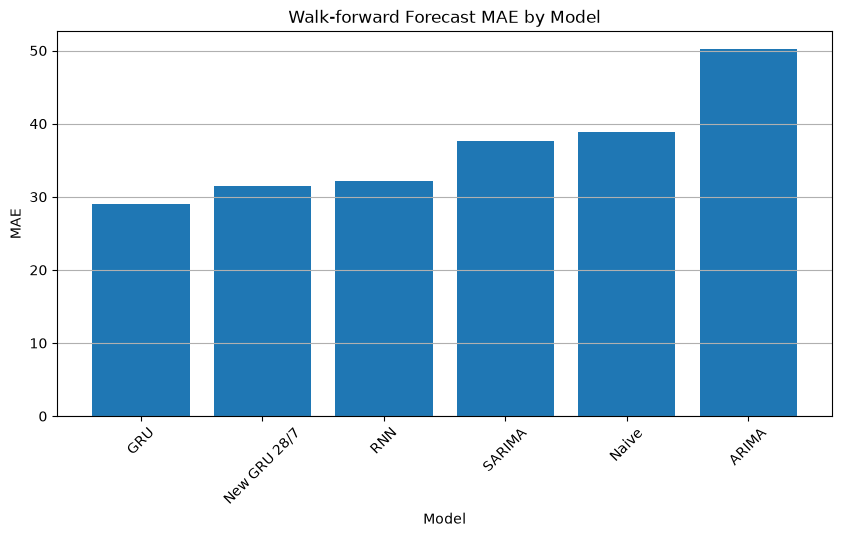

In [74]:
plt.figure(figsize=(10, 5))
plt.bar(overall_metrics_df["Model"], overall_metrics_df["MAE"])
plt.title("Walk-forward Forecast MAE by Model")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

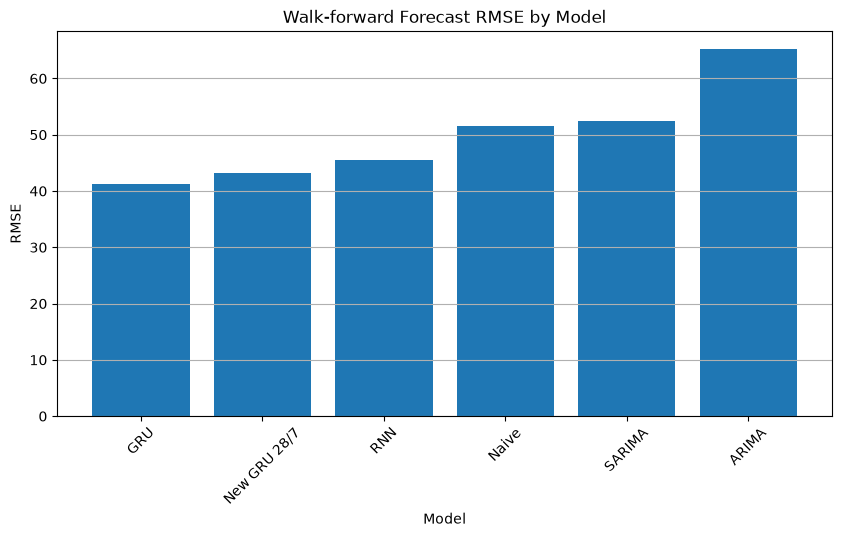

In [75]:
overall_rmse_df = overall_metrics_df.sort_values("RMSE").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(overall_rmse_df["Model"], overall_rmse_df["RMSE"])
plt.title("Walk-forward Forecast RMSE by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

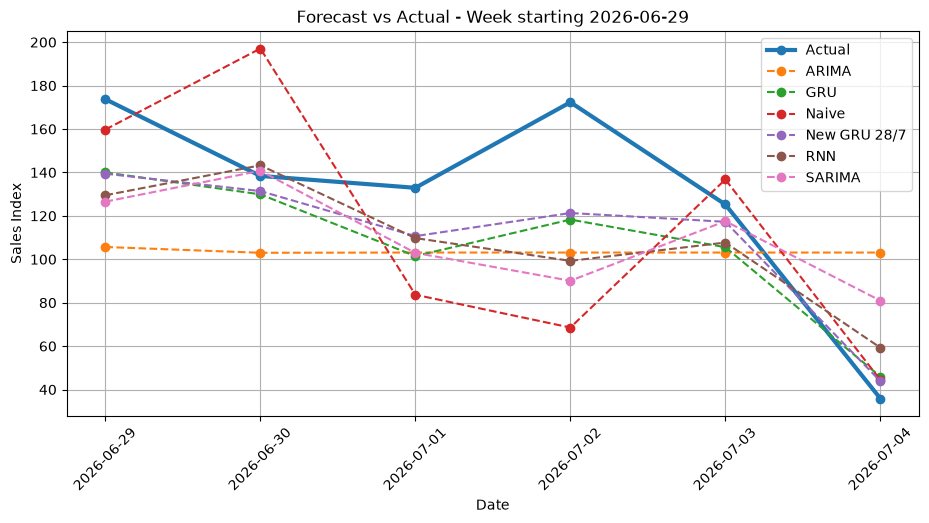

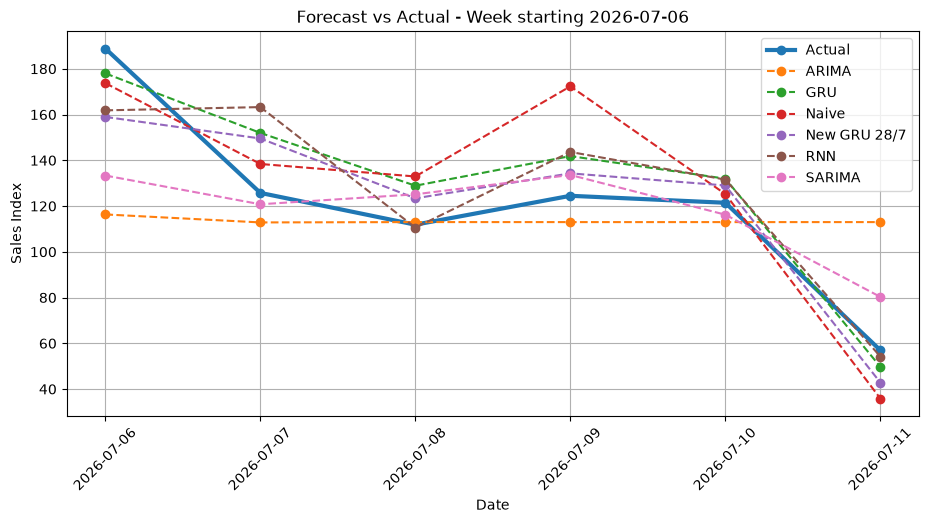

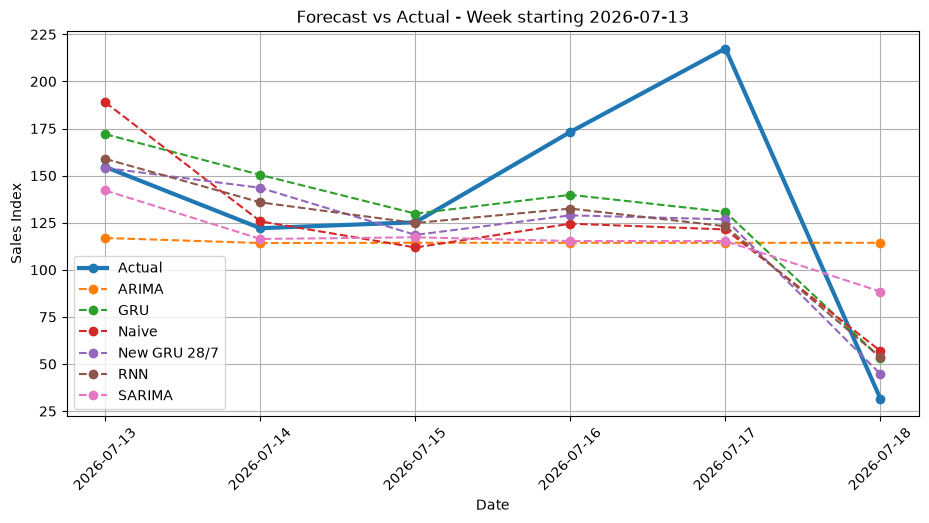

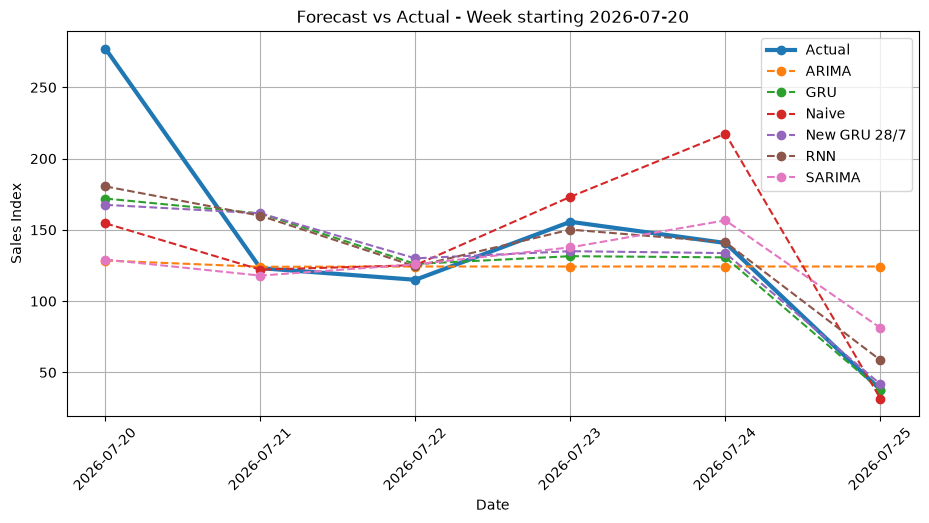

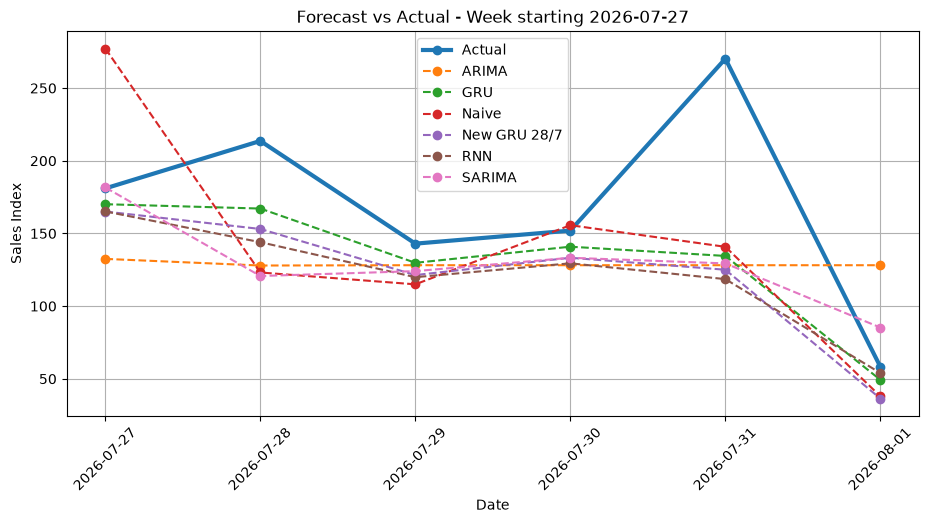

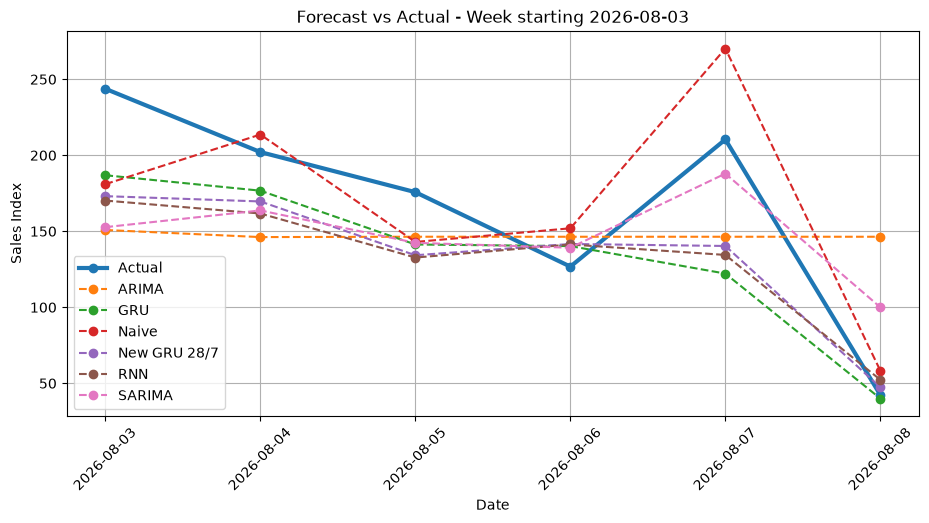

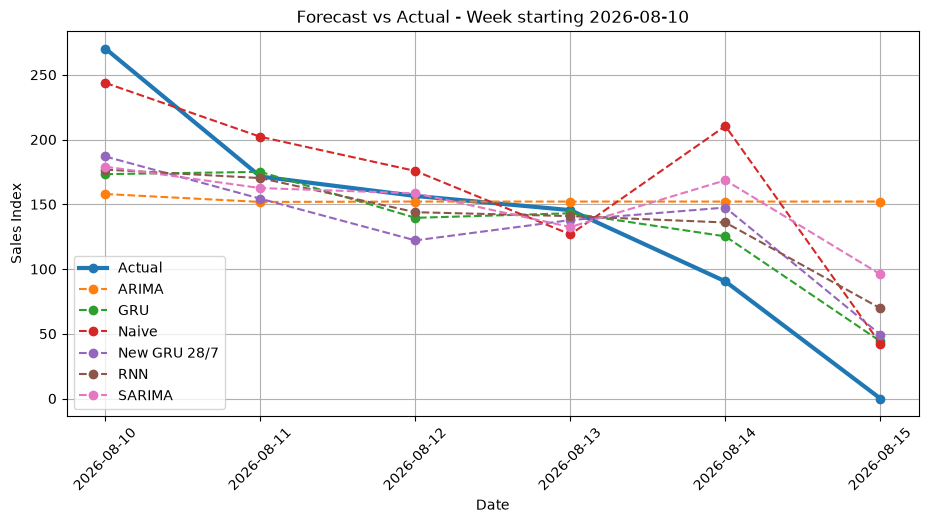

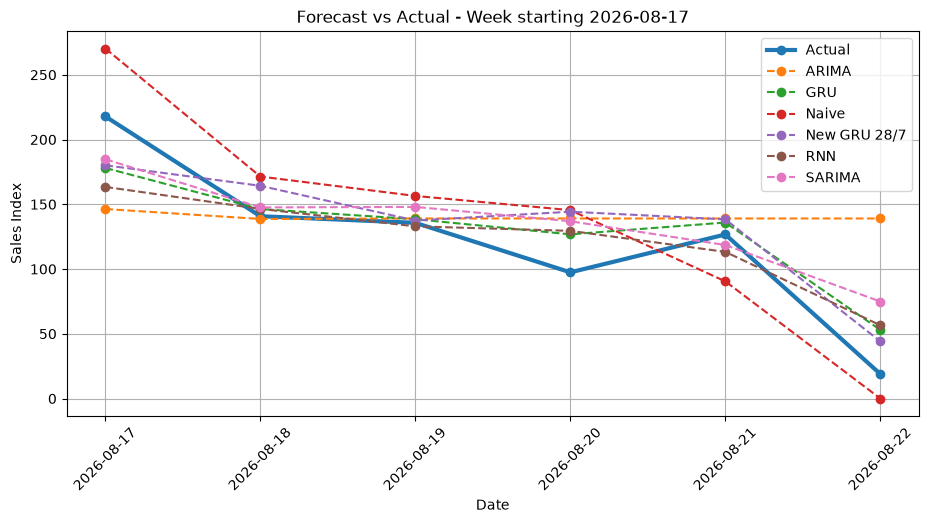

In [76]:
for week_start in sorted(all_results_df["week_start"].unique()):
    df_week = all_results_df[all_results_df["week_start"] == week_start].copy()

    plt.figure(figsize=(11, 5))

    actual_line = (
        df_week[["forecast_date", "y_true"]]
        .drop_duplicates()
        .sort_values("forecast_date")
    )

    plt.plot(
        actual_line["forecast_date"],
        actual_line["y_true"],
        marker="o",
        linewidth=3,
        label="Actual"
    )

    for model_name, df_model in df_week.groupby("model"):
        df_model = df_model.sort_values("forecast_date")

        plt.plot(
            df_model["forecast_date"],
            df_model["y_pred"],
            marker="o",
            linestyle="--",
            label=model_name
        )

    plt.title(f"Forecast vs Actual - Week starting {pd.Timestamp(week_start).date()}")
    plt.xlabel("Date")
    plt.ylabel("Sales Index")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.show()

In [77]:
all_results_df.to_csv("walk_forward_all_predictions.csv", index=False)
overall_metrics_df.to_csv("walk_forward_overall_metrics.csv", index=False)
weekly_metrics_df.to_csv("walk_forward_weekly_metrics.csv", index=False)
horizon_metrics_df.to_csv("walk_forward_horizon_metrics.csv", index=False)

In [78]:
display(overall_metrics_df)

,Model,MAE,RMSE
0,GRU,29.053585,41.193279
1,New GRU 28/7,31.511499,43.252481
2,RNN,32.219098,45.509648
3,SARIMA,37.692644,52.513470
4,Naive,38.826042,51.486631
5,ARIMA,50.149358,65.148995


Among the neural network models, the calendar-aware New GRU achieved the best overall walk-forward performance. The improvement was modest but consistent, especially at later forecast horizons. This suggests that adding calendar structure, Sunday zero-sales days, and weekday flags helped the model capture weekly sales patterns.

Although the GRU achieved the best overall performance, the results should not be interpreted as a complete explanation of sales behavior. The dataset contains only historical sales values, while real e-commerce sales are influenced by external business factors such as inventory availability, supplier lead times, cash-flow constraints, promotions, seasonality, holidays, and product-level demand changes. Therefore, the model is useful as a forecasting baseline, but not as a full business decision system.

The final walk-forward evaluation showed that neural recurrent models outperformed classical statistical baselines. The standard GRU achieved the lowest error, with MAE = 29.05 and RMSE = 41.19, improving over the naive baseline by approximately 25% in MAE. However, the margin between the neural models was not large, and the forecasting task remains noisy because many important business drivers are not included in the data. For real operational use, the model should be treated as a decision-support tool rather than an automatic sales prediction engine.